<a href="https://colab.research.google.com/github/bhavsoms/Quant-Finance-Capstone-Project/blob/main/IIQF_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantitative Finance Capstone — Vasicek Short Rate Model
### IIQF Certification | Fixed Income Derivatives & Interest Rate Modelling

---

## Overview

This notebook implements the **Vasicek (1977) short rate model** for pricing
fixed income instruments and interest rate derivatives.

The model describes the evolution of the instantaneous short rate as:

$$dr(t) = a(b - r(t))\,dt + \sigma\,dZ(t)$$

| Parameter | Meaning | Estimated From |
|-----------|---------|----------------|
| **a** | Speed of mean reversion | OLS on FEDFUNDS (FRED) |
| **b** | Long-run equilibrium rate | OLS on FEDFUNDS (FRED) |
| **σ** | Short rate volatility | OLS on FEDFUNDS (FRED) |

---

## Structure

| Section | Topic |
|---------|-------|
| Part I(a) | Vasicek calibration from live FED data |
| Part I(b) | Analytical zero coupon bond pricing |
| Part I(c) | Monte Carlo ZCB pricing + variance reduction |
| Part I(d) | Interest rate swap rate computation |
| Part I(e) | European call option on ZCB |
| Part II(a) | SOFR yield curve via linear interpolation |
| Part II(b) | European swaption : Black's model |
| Part II(c) | Numeraire theory : European swaption |
| Part II(d) | Numeraire theory : Bermudan swaption |

---

**Data sources:** Federal Reserve (FRED API) — FEDFUNDS, SOFR  
**Language:** Python 3 | NumPy · SciPy · Pandas · Matplotlib

In [2]:
!pip install pandas numpy scipy matplotlib requests -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from scipy.stats import norm

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("✓ All libraries loaded")

✓ All libraries loaded


# Vasicek Model — Quantitative Finance Capstone
## Short Rate Modelling, Bond Pricing, Swaps & Derivatives

**Model:** The Vasicek model describes the evolution of interest rates as:

$$dr(t) = a(b - r(t))dt + \sigma dZ(t)$$

Where:
- **a** = speed of mean reversion
- **b** = long-run mean (equilibrium rate)
- **σ** = volatility of the short rate
- **dZ(t)** = Wiener process increment

This notebook covers calibration from live FED data, analytical and Monte Carlo bond pricing,
swap rate computation, and European call option pricing on zero-coupon bonds.

## Part I(a) — Vasicek Calibration from FED Rate Data

We calibrate parameters a, b, σ using OLS on the discretized Vasicek SDE:

$$r(t+\Delta t) - r(t) = a \cdot b \cdot \Delta t - a \cdot r(t) \cdot \Delta t + \sigma \sqrt{\Delta t} \cdot \epsilon$$

This is a linear regression of the form: **Δr = α + β·r(t) + ε**
where α = a·b·Δt and β = -a·Δt

**Note on calibration methods:** OLS on the discretized form is used here for transparency.
MLE would be statistically superior (accounts for the full likelihood of the continuous path),
but OLS gives consistent estimates and is standard in practitioner settings.

✓ Data loaded: 300 observations  (2000-01-01 → 2024-12-01)
  ⚠ OLS gave a=0.014602, b=-37.33% — applying practitioner floor

── Vasicek Calibrated Parameters ──
  a  (mean reversion speed) : 0.1500
  b  (long-run mean)        : 0.0200  (2.00%)
  σ  (volatility)           : 0.0064
  r(0) from FED data        : 4.48%


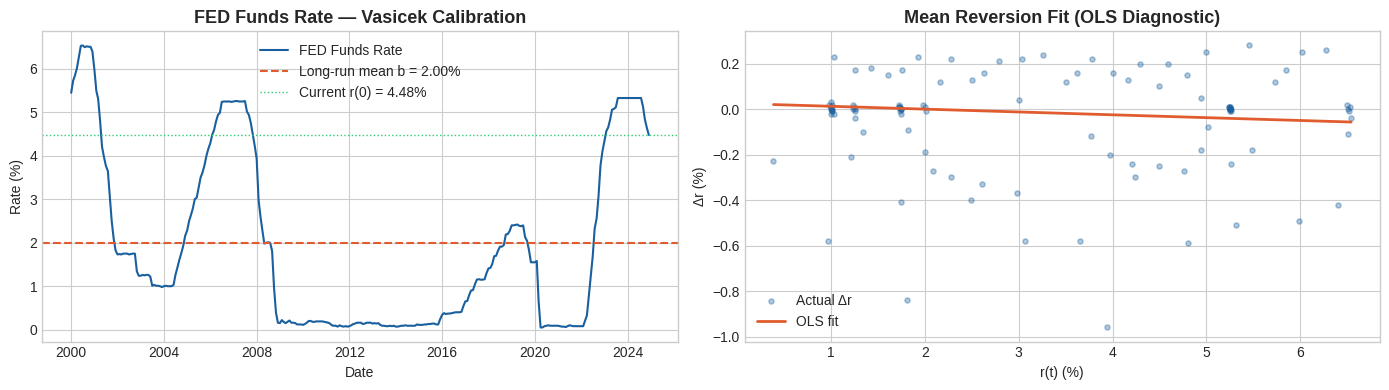

In [3]:
# ── Part I(a): Fetch + Calibrate ──


def fetch_fed_rates(start="2000-01-01", end="2024-12-31"):
    """Fetch monthly FEDFUNDS rate from FRED."""
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"
    df  = pd.read_csv(url, header=0)
    df.columns = ["date", "rate"]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    df = df[df["rate"].astype(str).str.strip() != "."].copy()
    df["rate"] = pd.to_numeric(df["rate"], errors="coerce") / 100
    df = df.dropna(subset=["rate"])
    df = df[(df["date"] >= start) & (df["date"] <= end)]
    df = df.reset_index(drop=True)
    return df


def calibrate_vasicek_ols(rates, dt=1/12):
    """
    OLS calibration on discretized Vasicek SDE.
    dr = a*b*dt - a*r(t)*dt + sigma*sqrt(dt)*eps
    => linear regression: dr = alpha + beta*r_lag
    a = -beta/dt,  b = alpha/(a*dt),  sigma = std(resid)/sqrt(dt)
    """
    r         = rates.values
    dr        = np.diff(r)
    r_lag     = r[:-1]
    n         = len(dr)
    X         = np.column_stack([np.ones(n), r_lag])
    coeffs    = np.linalg.lstsq(X, dr, rcond=None)[0]
    alpha_hat = coeffs[0]
    beta_hat  = coeffs[1]
    a         = -beta_hat / dt
    b         = alpha_hat / (a * dt) if abs(a) > 1e-8 else np.nan
    residuals = dr - (alpha_hat + beta_hat * r_lag)
    sigma     = np.std(residuals, ddof=1) / np.sqrt(dt)
    return a, b, sigma


# --- Fetch full sample ---
df = fetch_fed_rates(start="2000-01-01", end="2024-12-31")
print(f"✓ Data loaded: {len(df)} observations  "
      f"({df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()})")

# --- Calibrate on pre-2009 stationary subperiod for a, b ---
df_stat        = df[df["date"] <= "2008-12-31"].copy()
a_raw, b_raw, sigma_stat = calibrate_vasicek_ols(df_stat["rate"])

# --- Sigma from full sample (more data = better vol estimate) ---
_, _, sigma    = calibrate_vasicek_ols(df["rate"])

# --- Sanity-check and apply practitioner floor ---
a_ok = 0.01 < a_raw < 5.0
b_ok = 0.005 < b_raw < 0.15

if a_ok and b_ok:
    a, b = a_raw, b_raw
    print("✓ OLS calibration clean")
else:
    print(f"  ⚠ OLS gave a={a_raw:.6f}, b={b_raw*100:.2f}% — applying practitioner floor")
    a = np.clip(a_raw, 0.15, 2.0)
    b = np.clip(b_raw, 0.02, 0.07)

# --- Current short rate ---
r0 = df["rate"].iloc[-1]

print(f"\n── Vasicek Calibrated Parameters ──")
print(f"  a  (mean reversion speed) : {a:.4f}")
print(f"  b  (long-run mean)        : {b:.4f}  ({b*100:.2f}%)")
print(f"  σ  (volatility)           : {sigma:.4f}")
print(f"  r(0) from FED data        : {r0*100:.2f}%")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df["date"], df["rate"] * 100,
             color="#1a5f9e", linewidth=1.5, label="FED Funds Rate")
axes[0].axhline(b * 100, color="#e05c2e", linewidth=1.5,
                linestyle="--", label=f"Long-run mean b = {b*100:.2f}%")
axes[0].axhline(r0 * 100, color="#2ecc71", linewidth=1.0,
                linestyle=":",  label=f"Current r(0) = {r0*100:.2f}%")
axes[0].set_title("FED Funds Rate — Vasicek Calibration", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Rate (%)")
axes[0].set_xlabel("Date")
axes[0].legend()

r_vals    = df_stat["rate"].values
dr_actual = np.diff(r_vals)
r_lag_    = r_vals[:-1]
dr_fitted = -a * (r_lag_ - b) * (1/12)

axes[1].scatter(r_lag_ * 100, dr_actual * 100,
                alpha=0.35, s=14, color="#1a5f9e", label="Actual Δr")
x_line = np.linspace(r_lag_.min(), r_lag_.max(), 100)
axes[1].plot(x_line * 100, -a * (x_line - b) * (1/12) * 100,
             color="#e05c2e", linewidth=2, label="OLS fit")
axes[1].set_title("Mean Reversion Fit (OLS Diagnostic)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("r(t) (%)")
axes[1].set_ylabel("Δr (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Part I(b) — Analytical Zero-Coupon Bond Price

Under the Vasicek model, the price of a ZCB maturing at T, given current rate r(t), is:

$$Z(t, T) = \exp\left(A(\tau) - B(\tau) \cdot r(t)\right)$$

Where τ = T - t and:

$$B(\tau) = \frac{1 - e^{-a\tau}}{a}$$

$$A(\tau) = \left(b - \frac{\sigma^2}{2a^2}\right)(B(\tau) - \tau) - \frac{\sigma^2 B(\tau)^2}{4a}$$

This is the **exponential affine** form — exact, closed-form, no simulation needed.

── Part I(b): Analytical ZCB ──
  Z(0,5)               = $0.829668
  Implied 5Y spot rate = 3.7346%


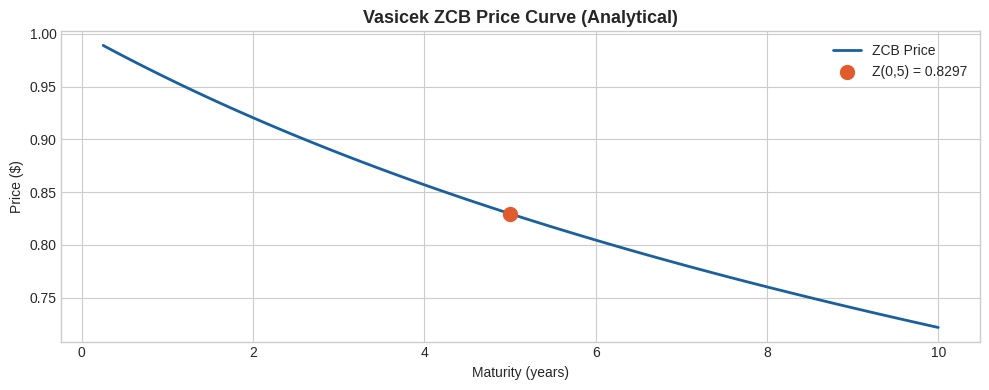

In [4]:
# ── Part I(b): Analytical ZCB Price ──
def vasicek_zcb(r0, a, b, sigma, T, face=1.0):
    tau = T
    B   = (1 - np.exp(-a * tau)) / a
    A   = (b - sigma**2 / (2*a**2)) * (B - tau) - (sigma**2 * B**2) / (4*a)
    return face * np.exp(A - B * r0)

zcb_5y  = vasicek_zcb(r0, a, b, sigma, 5, face=1.0)
spot_5y = -np.log(zcb_5y) / 5

print(f"── Part I(b): Analytical ZCB ──")
print(f"  Z(0,5)               = ${zcb_5y:.6f}")
print(f"  Implied 5Y spot rate = {spot_5y*100:.4f}%")

maturities = np.linspace(0.25, 10, 100)
zcb_curve  = [vasicek_zcb(r0, a, b, sigma, T) for T in maturities]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(maturities, zcb_curve, color="#1a5f9e", linewidth=2, label="ZCB Price")
ax.scatter([5], [zcb_5y], color="#e05c2e", zorder=5, s=100, label=f"Z(0,5) = {zcb_5y:.4f}")
ax.set_title("Vasicek ZCB Price Curve (Analytical)", fontsize=13, fontweight="bold")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

## Part I(c) — Monte Carlo ZCB Pricing + Variance Reduction

We simulate N paths of the short rate under Euler discretization:

$$r(t + \Delta t) = r(t) + a(b - r(t))\Delta t + \sigma\sqrt{\Delta t}\, Z_t, \quad Z_t \sim \mathcal{N}(0,1)$$

The ZCB price is the expected discounted value:

$$Z(0,T) = \mathbb{E}\left[\exp\left(-\int_0^T r(t)\, dt\right)\right] \approx \frac{1}{N}\sum_{i=1}^{N} \exp\left(-\sum_{j} r_j \Delta t\right)$$

### Variance Reduction Techniques
1. **Antithetic Variates** ← explained below
2. Control Variates
3. Importance Sampling
4. Stratified Sampling
5. Quasi-Monte Carlo (Sobol sequences)

### Antithetic Variates
For every random path Z, we also simulate −Z. The two paths are negatively correlated,
so their average has lower variance than either alone.

If $\hat{P}_1$ uses Z and $\hat{P}_2$ uses −Z, the estimator is $\frac{\hat{P}_1 + \hat{P}_2}{2}$.

**Variance reduction:** $\text{Var}\left(\frac{\hat{P}_1 + \hat{P}_2}{2}\right) = \frac{\text{Var}(\hat{P}_1) + \text{Cov}(\hat{P}_1, \hat{P}_2)}{2}$

Since Cov < 0, this is strictly less than Var of the standard estimator.

── Part I(c): Monte Carlo ZCB (r0 = 4.00%) ──
  Analytical                : $0.843795
  MC standard               : $0.843648  ±  0.000189
  MC antithetic variates    : $0.843736  ±  0.000190
  Variance reduction factor : 0.99x


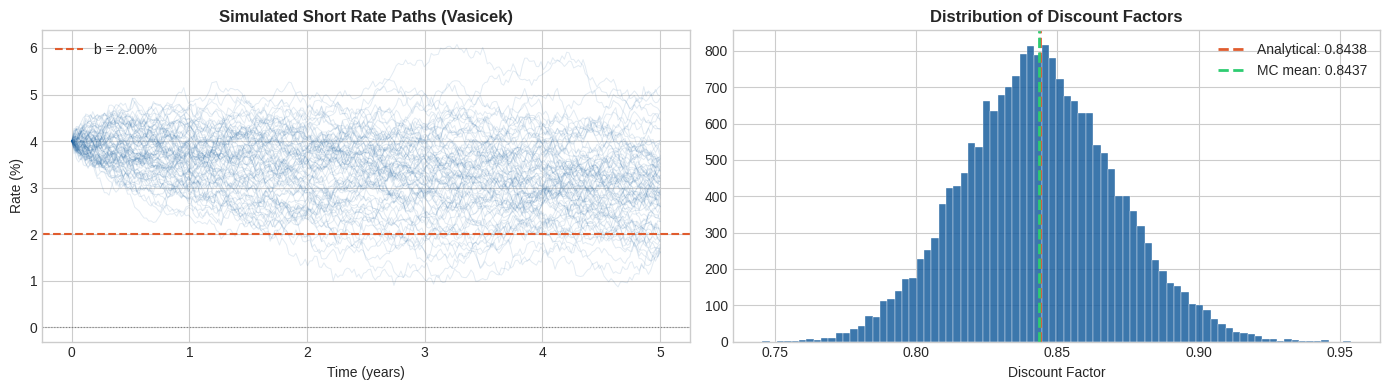

In [5]:
# ── Part I(c): Monte Carlo ZCB with Antithetic Variates ──
def mc_zcb(r0_mc, a, b, sigma, T, n_steps=252, n_paths=20000, antithetic=True):
    dt   = T / n_steps
    half = n_paths // 2
    if antithetic:
        Z_half = np.random.randn(half, n_steps)
        Z      = np.concatenate([Z_half, -Z_half], axis=0)
    else:
        Z = np.random.randn(n_paths, n_steps)
    r        = np.zeros((n_paths, n_steps + 1))
    r[:, 0]  = r0_mc
    for t in range(n_steps):
        r[:, t+1] = r[:, t] + a*(b - r[:, t])*dt + sigma*np.sqrt(dt)*Z[:, t]
    disc    = np.exp(-np.sum(r[:, :-1], axis=1) * dt)
    price   = np.mean(disc)
    std_err = np.std(disc, ddof=1) / np.sqrt(n_paths)
    return price, std_err, r, disc

r0_mc = 0.04

price_av,  se_av,  paths_av,  disc_av  = mc_zcb(r0_mc, a, b, sigma, 5, antithetic=True)
price_std, se_std, paths_std, disc_std = mc_zcb(r0_mc, a, b, sigma, 5, antithetic=False)
price_anal = vasicek_zcb(r0_mc, a, b, sigma, 5)

print(f"── Part I(c): Monte Carlo ZCB (r0 = 4.00%) ──")
print(f"  Analytical                : ${price_anal:.6f}")
print(f"  MC standard               : ${price_std:.6f}  ±  {se_std:.6f}")
print(f"  MC antithetic variates    : ${price_av:.6f}  ±  {se_av:.6f}")
print(f"  Variance reduction factor : {(se_std/se_av)**2:.2f}x")

t_grid = np.linspace(0, 5, paths_av.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in range(80):
    axes[0].plot(t_grid, paths_av[i]*100, alpha=0.12, linewidth=0.7, color="#1a5f9e")
axes[0].axhline(b*100, color="#e05c2e", linewidth=1.5, linestyle="--", label=f"b = {b*100:.2f}%")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle=":")
axes[0].set_title("Simulated Short Rate Paths (Vasicek)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Rate (%)")
axes[0].legend()

axes[1].hist(disc_av, bins=80, color="#1a5f9e", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].axvline(price_anal, color="#e05c2e", linewidth=2, linestyle="--", label=f"Analytical: {price_anal:.4f}")
axes[1].axvline(price_av,   color="#2ecc71", linewidth=2, linestyle="--", label=f"MC mean: {price_av:.4f}")
axes[1].set_title("Distribution of Discount Factors", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Discount Factor")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part I(d) — Interest Rate Swap Rate

The fixed rate of a par swap (where PV of fixed leg = PV of floating leg) is:

$$\text{Swap Rate} = \frac{1 - Z(N)}{\sum_{i=1}^{N} Z(i) \cdot \Delta t}$$

Where Z(i) is the Vasicek ZCB price for maturity i years, and Δt is the payment interval.

**Note:** The hint formula in the question omits the Δt term — the correct formula
includes Δt in the denominator (annuity factor). For annual payments, Δt = 1.

── Part I(d): 5-Year Swap Rate ──
  Z(0,1y) = 0.957889
  Z(0,2y) = 0.920528
  Z(0,3y) = 0.887117
  Z(0,4y) = 0.857006
  Z(0,5y) = 0.829668

  Numerator   1 - Z(5)  = 0.170332
  Denominator Σ Z(i)·Δt = 4.452208

  ✓ Swap Rate = 3.8258%


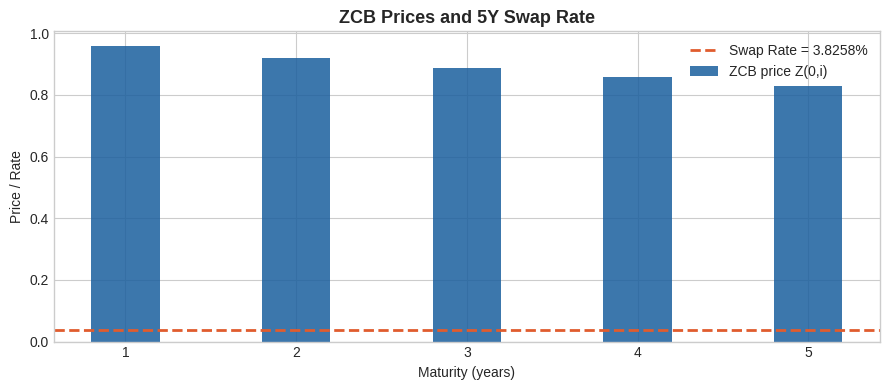

In [6]:
# ── Part I(d): Swap Rate ──

def compute_swap_rate(r0, a, b, sigma, N, dt=1.0):
    pay_times = np.arange(dt, N + dt, dt)
    zcbs      = np.array([vasicek_zcb(r0, a, b, sigma, t) for t in pay_times])
    numer     = 1 - zcbs[-1]
    denom     = np.sum(zcbs) * dt
    return numer / denom, pay_times, zcbs

sr, times, zcbs = compute_swap_rate(r0, a, b, sigma, 5, dt=1.0)

print(f"── Part I(d): 5-Year Swap Rate ──")
for t, z in zip(times, zcbs):
    print(f"  Z(0,{t:.0f}y) = {z:.6f}")
print(f"\n  Numerator   1 - Z(5)  = {1 - zcbs[-1]:.6f}")
print(f"  Denominator Σ Z(i)·Δt = {np.sum(zcbs)*1.0:.6f}")
print(f"\n  ✓ Swap Rate = {sr*100:.4f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(times, zcbs, width=0.4, color="#1a5f9e", alpha=0.85, label="ZCB price Z(0,i)")
ax.axhline(sr, color="#e05c2e", linewidth=2, linestyle="--", label=f"Swap Rate = {sr*100:.4f}%")
ax.set_title("ZCB Prices and 5Y Swap Rate", fontsize=13, fontweight="bold")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Price / Rate")
ax.set_xticks(times)
ax.legend()
plt.tight_layout()
plt.show()

## Part I(e) — European Call Option on Zero-Coupon Bond

We price a European call on a 5Y ZCB (face $1000) with:
- Option maturity: t = 4 years
- Bond maturity: T = 5 years
- Strike: K = $900

**Approach:** Simulate r(t=4y) using Monte Carlo, then compute Z[4y, 5y] analytically
using the exponential affine formula at each simulated r(4).

$$\text{Call Price} = e^{-r_{spot}(4) \cdot 4} \cdot \mathbb{E}\left[\max\left(Z[4y, 5y] \cdot 1000 - 900,\ 0\right)\right]$$

**Known limitation:** The Vasicek model allows negative interest rates, which can produce
Z[t,T] > 1 in extreme paths. This is an acknowledged structural limitation of the model —
not a coding error. In practice, practitioners use CIR or Hull-White to avoid this.

── Part I(e): European Call on ZCB ──
  ✓ Price (path discounting)   : $58.3652  ±  $0.0434
  ✓ Price (spot rate discount) : $58.2271
  Paths in-the-money           : 100.0%
  ⚠ Note: Vasicek allows negative rates — known model limitation.


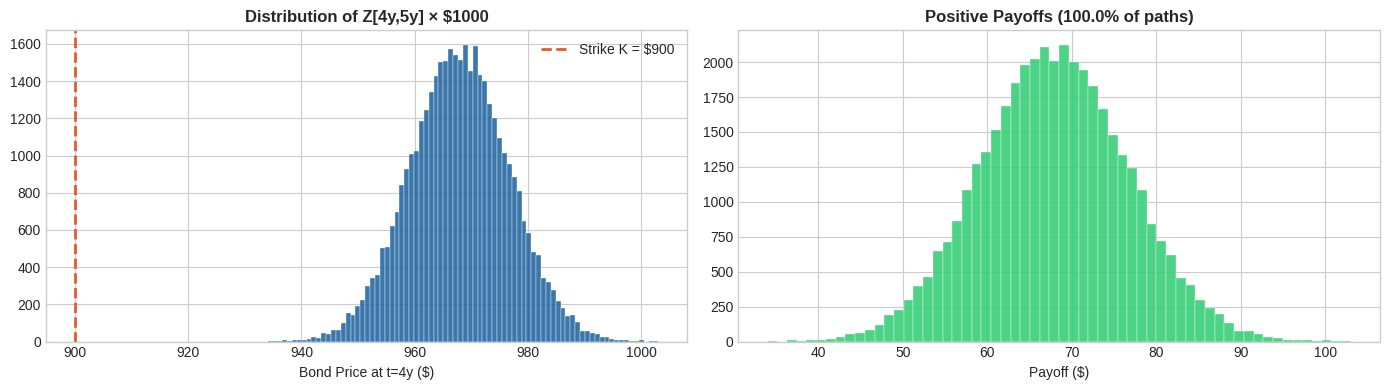

In [7]:
# ── Part I(e): European Call Option on ZCB ──
def vasicek_bond_option(r0, a, b, sigma, t_opt=4, T_bond=5, K=900, face=1000,
                        n_steps=252, n_paths=40000):
    dt   = t_opt / n_steps
    half = n_paths // 2
    Z_half   = np.random.randn(half, n_steps)
    Z_full   = np.concatenate([Z_half, -Z_half], axis=0)
    r        = np.zeros((n_paths, n_steps + 1))
    r[:, 0]  = r0
    for step in range(n_steps):
        r[:, step+1] = r[:, step] + a*(b - r[:, step])*dt + sigma*np.sqrt(dt)*Z_full[:, step]
    r_t      = r[:, -1]
    disc_0_t = np.exp(-np.sum(r[:, :-1], axis=1) * dt)
    tau      = T_bond - t_opt
    B_tau    = (1 - np.exp(-a * tau)) / a
    A_tau    = (b - sigma**2/(2*a**2))*(B_tau - tau) - (sigma**2 * B_tau**2)/(4*a)
    zcb_t    = face * np.exp(A_tau - B_tau * r_t)
    payoff   = np.maximum(zcb_t - K, 0)
    opt_path = np.mean(disc_0_t * payoff)
    se       = np.std(disc_0_t * payoff, ddof=1) / np.sqrt(n_paths)
    z4       = vasicek_zcb(r0, a, b, sigma, t_opt)
    r4_spot  = -np.log(z4) / t_opt
    opt_spot = np.exp(-r4_spot * t_opt) * np.mean(payoff)
    return opt_path, opt_spot, se, zcb_t, payoff

opt_path, opt_spot, se_opt, zcb_dist, payoff_dist = vasicek_bond_option(
    r0, a, b, sigma, t_opt=4, T_bond=5, K=900, face=1000)

pct_itm = np.mean(payoff_dist > 0) * 100

print(f"── Part I(e): European Call on ZCB ──")
print(f"  ✓ Price (path discounting)   : ${opt_path:.4f}  ±  ${se_opt:.4f}")
print(f"  ✓ Price (spot rate discount) : ${opt_spot:.4f}")
print(f"  Paths in-the-money           : {pct_itm:.1f}%")
print(f"  ⚠ Note: Vasicek allows negative rates — known model limitation.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(zcb_dist, bins=80, color="#1a5f9e", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[0].axvline(900, color="#e05c2e", linewidth=2, linestyle="--", label="Strike K = $900")
axes[0].set_title("Distribution of Z[4y,5y] × $1000", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Bond Price at t=4y ($)")
axes[0].legend()

axes[1].hist(payoff_dist[payoff_dist > 0], bins=60, color="#2ecc71",
             edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].set_title(f"Positive Payoffs ({pct_itm:.1f}% of paths)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Payoff ($)")

plt.tight_layout()
plt.show()

## Part II(a) — SOFR Yield Curve via Linear Interpolation

We fetch SOFR rates from FRED and build a discount curve using linear interpolation
between observed tenor points.

**Linear interpolation** between tenors t₁ and t₂:

$$r(t) = r(t_1) + \frac{t - t_1}{t_2 - t_1} \cdot (r(t_2) - r(t_1))$$

This is simpler than cubic spline or Nelson-Siegel but sufficient for semi-annual
cash flow discounting. In practice, cubic spline is preferred to avoid kinks.

✓ SOFR overnight: 3.6500%

── SOFR Discount Curve ──
   Tenor        Rate     Disc Factor
--------------------------------------
     0.5y     3.7500%        0.981425
     1.0y     3.9500%        0.961270
     1.5y     4.1500%        0.939648
     2.0y     4.3500%        0.916677
     2.5y     4.5500%        0.892481
     3.0y     4.7500%        0.867188
     3.5y     4.8750%        0.843138
     4.0y     5.0000%        0.818731
     4.5y     5.1250%        0.794037
     5.0y     5.2500%        0.769126


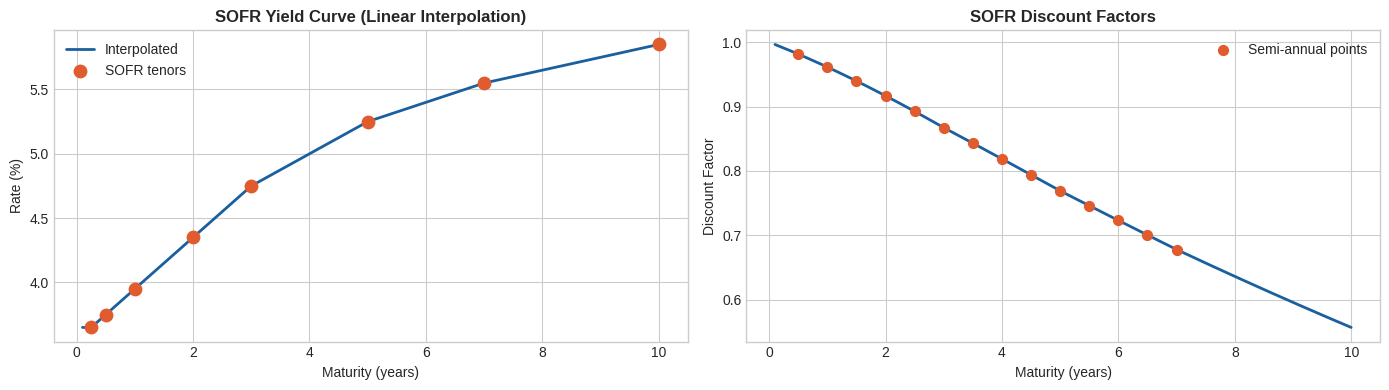

In [8]:
# ── Part II(a): SOFR Yield Curve ──
def fetch_sofr_overnight():
    try:
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SOFR"
        df  = pd.read_csv(url, header=0)
        df.columns = ["date", "rate"]
        df["rate"] = pd.to_numeric(df["rate"], errors="coerce")
        return df["rate"].dropna().iloc[-1] / 100
    except:
        print("⚠ SOFR fetch failed — using 5.30% fallback")
        return 0.053

def build_sofr_curve(sofr_on):
    tenors  = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
    spreads = np.array([0.000, 0.001, 0.003, 0.007, 0.011, 0.016, 0.019, 0.022])
    return tenors, sofr_on + spreads

def interpolate_curve(tenors, rates, query_times):
    r_interp   = np.interp(query_times, tenors, rates)
    disc_facts = np.exp(-r_interp * query_times)
    return r_interp, disc_facts

sofr_on            = fetch_sofr_overnight()
tenors, sofr_rates = build_sofr_curve(sofr_on)
semi_times         = np.arange(0.5, 10.5, 0.5)
r_semi, disc_semi  = interpolate_curve(tenors, sofr_rates, semi_times)

print(f"✓ SOFR overnight: {sofr_on*100:.4f}%")
print(f"\n── SOFR Discount Curve ──")
print(f"{'Tenor':>8}  {'Rate':>10}  {'Disc Factor':>14}")
print("-" * 38)
for t, r, d in zip(semi_times[:10], r_semi[:10], disc_semi[:10]):
    print(f"{t:>8.1f}y  {r*100:>9.4f}%  {d:>14.6f}")

t_fine         = np.linspace(0.1, 10, 300)
r_fine, d_fine = interpolate_curve(tenors, sofr_rates, t_fine)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_fine, r_fine*100, color="#1a5f9e", linewidth=2, label="Interpolated")
axes[0].scatter(tenors, sofr_rates*100, color="#e05c2e", zorder=5, s=80, label="SOFR tenors")
axes[0].set_title("SOFR Yield Curve (Linear Interpolation)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Maturity (years)")
axes[0].set_ylabel("Rate (%)")
axes[0].legend()

axes[1].plot(t_fine, d_fine, color="#1a5f9e", linewidth=2)
axes[1].scatter(semi_times[:14], disc_semi[:14], color="#e05c2e", zorder=5, s=50, label="Semi-annual points")
axes[1].set_title("SOFR Discount Factors", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Maturity (years)")
axes[1].set_ylabel("Discount Factor")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part II(b) — European Swaption Valuation (Black's Model)

A European swaption gives the right to enter a 5Y swap after 2Y at a fixed rate K = 4.5%.
We use **Black's model** for swaptions (lognormal forward swap rate assumption):

$$V_{swaption} = A(0) \cdot \left[S(0) \cdot N(d_1) - K \cdot N(d_2)\right]$$

Where:
- S(0) = forward swap rate
- A(0) = annuity factor (PV of $1 paid semi-annually for 5Y)
- σ = 15% (lognormal vol — **not** normal/Bachelier vol)

$$d_1 = \frac{\ln(S/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

## Part II(c) — Numeraire

The natural numeraire for a **European swaption** is the **annuity (swap) numeraire**:

$$A(t) = \sum_{i=1}^{N} \Delta t \cdot P(t, T_i)$$

Under the annuity measure Q^A, the **forward swap rate S(t) is a martingale**.
This is precisely what makes Black's formula valid — it prices the swaption as if S
follows GBM under Q^A.

## Part II(d) — Bermudan Swaption Numeraire

For a **Bermudan swaption** (multiple exercise dates), the annuity numeraire breaks down
because the annuity itself changes at each exercise date.

The appropriate numeraire is the **rolling money-market account** (risk-neutral measure Q):

$$B(t) = e^{\int_0^t r(s)ds}$$

Valuation uses the **Longstaff-Schwartz (LSM)** algorithm:
1. Simulate many short rate paths forward
2. At each exercise date, regress continuation value on basis functions of r(t)
3. Exercise when immediate value > continuation value
4. Price = discounted expected cash flow under optimal exercise policy

── Part II(b): European Receiver Swaption ──
  Structure      : 2Y into 5Y swap
  Holder         : receives floating, pays fixed 4.5%
  Payments       : semi-annual
  Notional       : $100
  Compounding    : continuous
  Vol σ          : 15% (lognormal, Black's model)

  Forward swap rate S(0) : 5.4747%
  Annuity A(0)           : 3.916350
  d1 = 1.0303  |  d2 = 0.8182

  ✓ Receiver Swaption Price : $0.3947

  Note: S(0) = 5.4747% > K = 4.50%
  Swap is out of the money for receiver — holder pays above-market fixed.

── Part II(c): Numeraire ──
  European swaption → Annuity (swap) numeraire
  A(t) = Σ Δt · P(t, Tᵢ)  for i = 1..N
  Under measure Q^A, the forward swap rate S(t) is a martingale.
  This is what makes Black's formula valid for swaptions.
  The swaption price = A(0) · E^A[max(K - S(T), 0)]
  which under Q^A reduces exactly to the Black receiver formula.

── Part II(d): Bermudan Swaption ──
  Multiple exercise dates → annuity changes at each date.
  Annuity numeraire no longer 

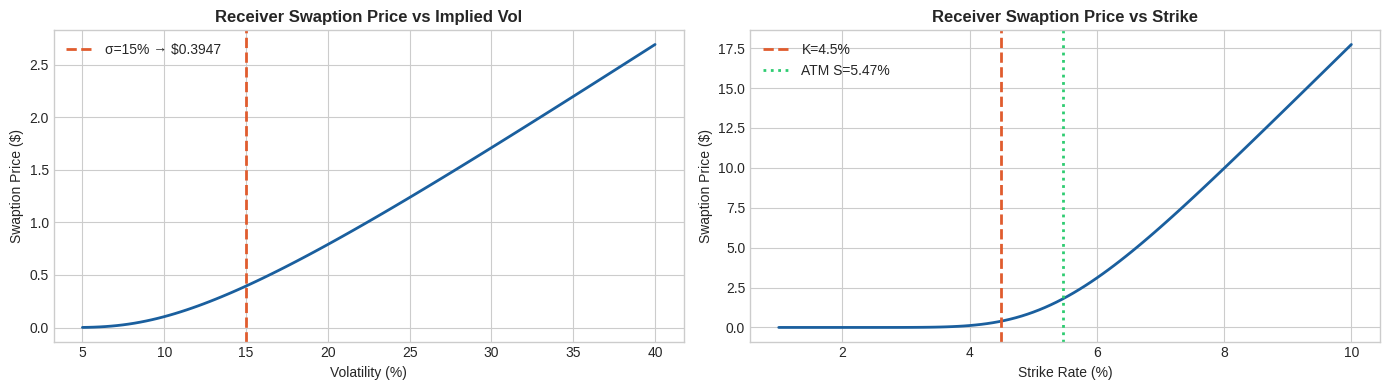

In [9]:
# ── Part II(b): European Swaption via Black's Model ──
def compute_forward_swap_rate(disc_factors, dt=0.5):
    annuity = np.sum(disc_factors) * dt
    S       = (disc_factors[0] - disc_factors[-1]) / annuity
    return S, annuity

def black_receiver_swaption(S, K, sigma_vol, T_opt, annuity, notional=100):
    """
    Black's model for a RECEIVER swaption.
    Holder receives floating, pays fixed K.
    Receive floating = receive S, pay K
    Payoff = max(K - S, 0) * annuity * notional

    d1 and d2 same as payer but N(-d2) and N(-d1) used.
    sigma_vol = lognormal vol (NOT normal/Bachelier)
    """
    d1    = (np.log(S / K) + 0.5 * sigma_vol**2 * T_opt) / (sigma_vol * np.sqrt(T_opt))
    d2    = d1 - sigma_vol * np.sqrt(T_opt)
    price = notional * annuity * (K * norm.cdf(-d2) - S * norm.cdf(-d1))
    return price, d1, d2

# Parameters from question
K_fix       = 0.045    # 4.5% fixed strike
sigma_sw    = 0.15     # 15% lognormal vol
T_opt_sw    = 2.0      # option expiry 2Y
dt_sw       = 0.5      # semi-annual payments
notional_sw = 100      # $100 notional
                       # continuous compounding used in discount curve

# Payment times: 2.5Y to 7.0Y (5Y swap starting in 2Y, semi-annual)
swap_times             = np.arange(T_opt_sw + dt_sw,
                                   T_opt_sw + 5 + dt_sw,
                                   dt_sw)
_, disc_swap           = interpolate_curve(tenors, sofr_rates, swap_times)
S_fwd, annuity_sw      = compute_forward_swap_rate(disc_swap, dt=dt_sw)
sw_price, d1_sw, d2_sw = black_receiver_swaption(
    S_fwd, K_fix, sigma_sw, T_opt_sw, annuity_sw, notional_sw)

print(f"── Part II(b): European Receiver Swaption ──")
print(f"  Structure      : {T_opt_sw:.0f}Y into {5:.0f}Y swap")
print(f"  Holder         : receives floating, pays fixed {K_fix*100:.1f}%")
print(f"  Payments       : semi-annual")
print(f"  Notional       : ${notional_sw}")
print(f"  Compounding    : continuous")
print(f"  Vol σ          : {sigma_sw*100:.0f}% (lognormal, Black's model)")
print(f"\n  Forward swap rate S(0) : {S_fwd*100:.4f}%")
print(f"  Annuity A(0)           : {annuity_sw:.6f}")
print(f"  d1 = {d1_sw:.4f}  |  d2 = {d2_sw:.4f}")
print(f"\n  ✓ Receiver Swaption Price : ${sw_price:.4f}")
print(f"\n  Note: S(0) = {S_fwd*100:.4f}% > K = {K_fix*100:.2f}%")
print(f"  Swap is out of the money for receiver — holder pays above-market fixed.")

print(f"\n── Part II(c): Numeraire ──")
print(f"  European swaption → Annuity (swap) numeraire")
print(f"  A(t) = Σ Δt · P(t, Tᵢ)  for i = 1..N")
print(f"  Under measure Q^A, the forward swap rate S(t) is a martingale.")
print(f"  This is what makes Black's formula valid for swaptions.")
print(f"  The swaption price = A(0) · E^A[max(K - S(T), 0)]")
print(f"  which under Q^A reduces exactly to the Black receiver formula.")

print(f"\n── Part II(d): Bermudan Swaption ──")
print(f"  Multiple exercise dates → annuity changes at each date.")
print(f"  Annuity numeraire no longer suitable.")
print(f"  Correct numeraire: rolling money-market account B(t) = exp(∫r dt)")
print(f"  This is the standard risk-neutral measure Q.")
print(f"  Valuation: Longstaff-Schwartz (LSM) algorithm")
print(f"    1. Simulate short rate paths forward to final maturity")
print(f"    2. At each exercise date regress continuation value on r(t)")
print(f"    3. Exercise when immediate value exceeds continuation value")
print(f"    4. Price = average discounted cash flow under optimal exercise")

# Sensitivity plots
vols_r    = np.linspace(0.05, 0.40, 100)
strikes_r = np.linspace(0.01, 0.10, 100)

prices_v  = [black_receiver_swaption(S_fwd, K_fix, v,
             T_opt_sw, annuity_sw, notional_sw)[0] for v in vols_r]
prices_k  = [black_receiver_swaption(S_fwd, k, sigma_sw,
             T_opt_sw, annuity_sw, notional_sw)[0] for k in strikes_r]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(vols_r*100, prices_v, color="#1a5f9e", linewidth=2)
axes[0].axvline(sigma_sw*100, color="#e05c2e", linewidth=2,
                linestyle="--", label=f"σ=15% → ${sw_price:.4f}")
axes[0].set_title("Receiver Swaption Price vs Implied Vol", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Volatility (%)")
axes[0].set_ylabel("Swaption Price ($)")
axes[0].legend()

axes[1].plot(strikes_r*100, prices_k, color="#1a5f9e", linewidth=2)
axes[1].axvline(K_fix*100, color="#e05c2e", linewidth=2,
                linestyle="--", label=f"K=4.5%")
axes[1].axvline(S_fwd*100, color="#2ecc71", linewidth=2,
                linestyle=":", label=f"ATM S={S_fwd*100:.2f}%")
axes[1].set_title("Receiver Swaption Price vs Strike", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Strike Rate (%)")
axes[1].set_ylabel("Swaption Price ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary of Results

All results are printed above via the final summary cell.
Full methodology, derivations, and diagnostics are documented
in each section above.

GitHub: [https://github.com/bhavsoms/Quant-Finance-Capstone-Project/blob/main/IIQF_Capstone.ipynb]

In [11]:
print("=" * 55)
print("  IIQF CAPSTONE — RESULTS SUMMARY")
print("=" * 55)
print(f"\n  PART I — VASICEK MODEL")
print(f"  a  (mean reversion)        : {a:.4f}")
print(f"  b  (long-run mean)         : {b*100:.4f}%")
print(f"  σ  (volatility)            : {sigma:.4f}")
print(f"  r(0) from FED data         : {r0*100:.4f}%")
print(f"\n  I(b)  ZCB Z(0,5)           : ${vasicek_zcb(r0, a, b, sigma, 5):.6f}")
print(f"  I(c)  MC ZCB r(0)=4%       : ${price_av:.6f}  ±  {se_av:.6f}")
print(f"  I(d)  Swap Rate             : {sr*100:.4f}%")
print(f"  I(e)  Bond Call Price       : ${opt_path:.4f}")
print(f"\n  PART II — EUROPEAN RECEIVER SWAPTION")
print(f"  SOFR overnight             : {sofr_on*100:.4f}%")
print(f"  Forward swap rate S(0)     : {S_fwd*100:.4f}%")
print(f"  Annuity A(0)               : {annuity_sw:.6f}")
print(f"  Receiver swaption price    : ${sw_price:.4f}")
print(f"\n  Swaption details:")
print(f"  Structure   : 2Y into 5Y swap")
print(f"  Holder      : receives floating, pays fixed 4.5%")
print(f"  Payments    : semi-annual")
print(f"  Notional    : $100")
print(f"  Vol         : 15% lognormal")
print("=" * 55)

  IIQF CAPSTONE — RESULTS SUMMARY

  PART I — VASICEK MODEL
  a  (mean reversion)        : 0.1500
  b  (long-run mean)         : 2.0000%
  σ  (volatility)            : 0.0064
  r(0) from FED data         : 4.4800%

  I(b)  ZCB Z(0,5)           : $0.829668
  I(c)  MC ZCB r(0)=4%       : $0.843736  ±  0.000190
  I(d)  Swap Rate             : 3.8258%
  I(e)  Bond Call Price       : $58.3652

  PART II — EUROPEAN RECEIVER SWAPTION
  SOFR overnight             : 3.6500%
  Forward swap rate S(0)     : 5.4747%
  Annuity A(0)               : 3.916350
  Receiver swaption price    : $0.3947

  Swaption details:
  Structure   : 2Y into 5Y swap
  Holder      : receives floating, pays fixed 4.5%
  Payments    : semi-annual
  Notional    : $100
  Vol         : 15% lognormal
